<a href="https://colab.research.google.com/github/zly554411-arch/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Phase 1: Bootstrapping Non-Parametric Uncertainty
Step 1.1: The Zero-Inflated Gig Economy Tip Distribution

In [6]:
# Data Generating Process
import numpy as np

np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

Step 1.2: The Manual Bootstrap Engine


In [7]:
# Architect a Manual Bootstrap Engine
bootstrap = 10000
n = len(driver_tips)
boot_medians = np.empty(bootstrap)

for i in range(bootstrap):
    resample = np.random.choice(driver_tips, size=n, replace=True)
    boot_medians[i] = np.median(resample)

# 95% Confidence Interval
ci_lower, ci_upper = np.percentile(boot_medians, [2.5, 97.5])
resample_median = np.median(driver_tips)
lower_margin = resample_median - ci_lower
upper_margin = ci_upper - resample_median

print(f"95% Confidence Interval:[${ci_lower:.4f}, ${ci_upper:.4f}]")

95% Confidence Interval:[$0.2653, $1.3636]


Since the dataset is heavily right-skewed, with a large proportion of users tipping exactly $0, the distribution of tips is not symmetric. This concentration of zero values and the presence of a long right tail create an asymmetric sampling distribution of the median. As a result, the bootstrap confidence interval is also asymmetric, unlike a standard parametric confidence interval that typically assumes a normal distribution.

#Phase 2: Falsification in Logistics A/B Testing
Step 2.1: The Algorithmic Routing Crash

In [8]:
# Data Generating Process
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)
observed_difference = np.mean(control) - np.mean(treatment)

print(f"Observed difference: {observed_difference:.4f}")

Observed difference: 2.1147


Step 2.2: The Exact Non-Parametric Permutation


In [9]:
# Combine All Deliveries
combined = np.concatenate([control, treatment])

# Cut the deck (50/50 split)
n = int(len(combined))
split_point = int(n * 0.5)

n_permu = 5000
permu_difference = np.empty(n_permu)

for i in range(n_permu):
  indices = np.random.permutation(n)

  # Slicing the shuffled indices
  group1_idx = indices[:split_point]
  group2_idx = indices[split_point:]

  # Creating the subsets
  group1_set = combined[group1_idx]
  group2_set = combined[group2_idx]


  permu_difference[i] = np.mean(group1_set) - np.mean(group2_set)

p_value = np.mean(np.abs(permu_difference) >= abs(observed_difference))

print(f"P-value: {p_value:.4f}")

P-value: 0.0022


#Phase 3: Causal Control and the Mitigation of Selection Bias
Step 3.1: The Loyalty Program Paradox


In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv('sample_data/swiftcart_loyalty.csv')

# Naive Comparison
naive_diff = df[df.subscriber==1]['post_spend'].mean() - df[df.subscriber==0]['post_spend'].mean()
print(f"Naive Difference in Means: ${naive_diff:,.2f}")

Naive Difference in Means: $17.57


Step 3.2: Propensity Score Matching (PSM) Architecture


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Define Covariates
X = df[['pre_spend','account_age', 'support_tickets']]
y = df['subscriber']

# Fit Propensity Model
logit = LogisticRegression(solver='liblinear')
logit.fit(X, y)

# Generate Scores
df['pscore'] = logit.predict_proba(X)[:, 1]

In [12]:
# Separate Groups
treated = df[df.subscriber==1]
control = df[df.subscriber==0]

# Fit NN on Control Scores
nbrs = NearestNeighbors(n_neighbors=1).fit(control[['pscore']])

# Find Matches for Treated Scores
distances, indices = nbrs.kneighbors(treated[['pscore']])
matched_control = control.iloc[indices.flatten()]

# Construct Matched DataFrame
matched_df = pd.concat([treated, matched_control])

# Average Treatment Effect on the Treated (ATT)
ATT = treated['post_spend'].mean() - matched_control['post_spend'].mean()
print(f"Estimated ATT after Propensity Score Matching: ${ATT:,.2f}")

Estimated ATT after Propensity Score Matching: $10.14


The Naive Simple Difference in Means (SDO) compares the average post-treatment spending of SwiftPass subscribers and non-subscribers. Based only on this comparison, the marketing team concludes that subscribers spend significantly more per month than non-subscribers. However, this method can lead to biased results because it ignores selection bias. Users who subscribe to the SwiftPass loyalty program may already differ systematically from those who do not. For example, users with higher pre-treatment spending, longer account histories, or more frequent use of the app are more likely to subscribe in order to save on delivery fees. As a result, the naive SDO captures both the true effect of the program and the pre-existing differences between users.

Propensity Score Matching (PSM) helps reduce this bias by controlling for observable pre-treatment characteristics. In this analysis, variables such as pre-treatment spending, account age, and historical support tickets are used to estimate the probability that a user subscribes to SwiftPass. Each subscriber is then matched with a non-subscriber who has a similar propensity score, creating a more comparable control group. This matching process allows us to better approximate the counterfactual outcome—what subscribers would have spent if they had not joined the program.

In this example, the naive SDO estimates a spending difference of 17.57 dollar, while the PSM estimate (ATT) is 10.14 dollar. The smaller ATT suggests that a large portion of the difference observed in the naive comparison is due to self-selection of high-usage customers into the loyalty program, rather than the causal effect of the program itself. Therefore, relying only on the naive SDO would overestimate the true impact of the SwiftPass loyalty program on user spending.

Task 4.1: The "Love Plot" Visualization Directive


/tmp/ipykernel_168/2077729774.py:52: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


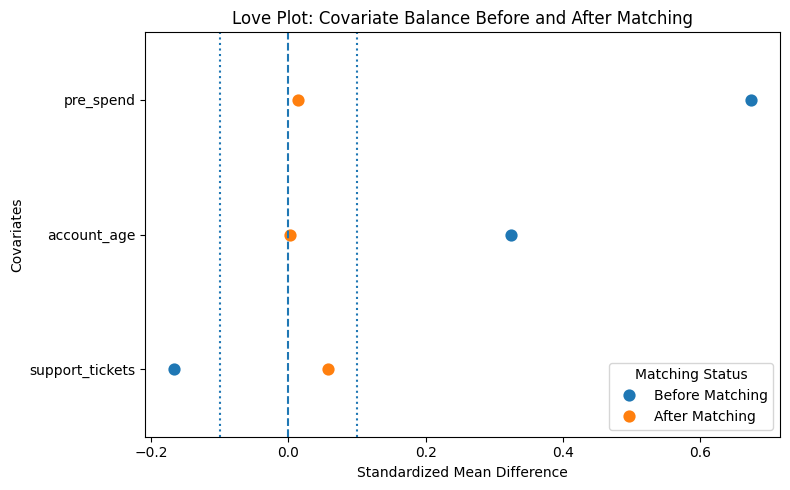

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define datasets
df_unmatched = df.copy()
df_matched = matched_df.copy()

# Covariates used in matching
covariates = ['pre_spend', 'account_age', 'support_tickets']

# Function to compute Standardized Mean Differences
def standardized_mean_diff(df, covariates, treat_col='subscriber'):

    treated = df[df[treat_col] == 1]
    control = df[df[treat_col] == 0]

    smd = {}

    for var in covariates:
        mean_t = treated[var].mean()
        mean_c = control[var].mean()

        sd_pooled = np.sqrt((treated[var].var() + control[var].var()) / 2)

        smd[var] = (mean_t - mean_c) / sd_pooled

    return pd.Series(smd)

# Compute balance statistics
smd_before = standardized_mean_diff(df_unmatched, covariates)
smd_after = standardized_mean_diff(df_matched, covariates)

# Combine results
love_df = pd.DataFrame({
    "Covariate": covariates,
    "Before Matching": smd_before.values,
    "After Matching": smd_after.values
})

# Convert to long format
love_long = love_df.melt(
    id_vars="Covariate",
    var_name="Matching Status",
    value_name="Standardized Mean Difference"
)

# Plot Love Plot
plt.figure(figsize=(8,5))

sns.pointplot(
    data=love_long,
    x="Standardized Mean Difference",
    y="Covariate",
    hue="Matching Status",
    join=False
)

# Reference lines
plt.axvline(0, linestyle="--")
plt.axvline(0.1, linestyle=":")
plt.axvline(-0.1, linestyle=":")

plt.title("Love Plot: Covariate Balance Before and After Matching")
plt.xlabel("Standardized Mean Difference")
plt.ylabel("Covariates")

plt.tight_layout()
plt.show()